In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.func import vmap, grad, functional_call, jacrev, vjp
torch.set_float32_matmul_precision("high")
import wandb
from accelerate.test_utils.testing import get_backend
device, n_devices, _ = get_backend()

# # Simulated data (A_i, ∇R(A_i))
# A_data = torch.randn(50, 5)  # Random 2D tensor
# true_theta = torch.tensor([2.0, 0.5])  # True parameters for R(A, theta)
# true_gradients = true_theta[0] * true_theta[1] * torch.exp(true_theta[1] * A_data)  # Simulated ∇R(A_i)

# # Define a learnable model for R(A, θ)
# class RFunction(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.tensor([1.0, 1.0]))  # Initialize parameters

#     def forward(self, A):
#         return torch.sum(self.theta[0] * torch.exp(self.theta[1] * A))  # Example function R(A, θ)

# # Instantiate model
# model = RFunction()
# optimizer = optim.Adam(model.parameters(), lr=0.1)
# loss_fn = nn.MSELoss()


# # Training loop to fit ∇R(A, θ) to observed gradients
# for epoch in range(100):

#     optimizer.zero_grad()

#     # RE-CREATE A_data with requires_grad=True at every step
#     A_data = A_data.detach().requires_grad_()

#     # Compute predicted gradient ∇R(A, θ) via autograd
#     R_values = model(A_data)
#     gradients = torch.autograd.grad(R_values, A_data, create_graph=True)[0]

#     # Compute loss
#     loss = loss_fn(gradients, true_gradients)
    
#     # Compute gradients of loss w.r.t. θ
#     # Backpropagate and update θ
#     loss.backward()
#     optimizer.step()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}: Loss = {loss.item()}")

# # Learned parameters
# print("Learned theta:", model.theta.detach().numpy())

In [2]:


# # Define your RFunction model (unchanged)
# class RFunction(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.tensor([1.0, 1.0]))  # Initialize parameters

#     def forward(self, A):
#         return torch.sum(self.theta[0] * torch.exp(self.theta[1] * A))  # Example function R(A, θ)

# # For this example, we'll use the same simulated data, but in batches
# A_data = torch.randn(500, 5)  # More data points
# true_theta = torch.tensor([2.0, 0.5]) 
# true_gradients = true_theta[0] * true_theta[1] * torch.exp(true_theta[1] * A_data)  # Simulated ∇R(A_i)
# # Make sure to reshape true_gradients to match the batch size

# # Create dataset and dataloader
# dataset = TensorDataset(A_data, true_gradients)
# batch_size = 32
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# # Instantiate model
# model = RFunction()
# optimizer = optim.Adam(model.parameters(), lr=0.1)
# loss_fn = nn.MSELoss()

# # Training loop with batches
# num_epochs = 30

# for epoch in range(num_epochs):
#     epoch_loss = 0.0
#     batch_count = 0
    
#     for A_batch, true_gradients_batch in dataloader:
#         optimizer.zero_grad()
        
#         # Make inputs require gradients
#         A_batch = A_batch.detach().requires_grad_()
        
#         # Compute predicted gradient ∇R(A, θ) via autograd
#         R_values = model(A_batch)
#         gradients = torch.autograd.grad(R_values, A_batch, create_graph=True)[0]
        
#         # Compute loss for this batch

#         loss = loss_fn(gradients, true_gradients_batch)
        
#         # Backpropagate and update θ
#         loss.backward()
#         optimizer.step()
        
#         epoch_loss += loss.item()
#         batch_count += 1
    
#     avg_epoch_loss = epoch_loss / batch_count
#     print(f"Epoch {epoch}: Average Loss = {avg_epoch_loss:.8f}")

# # Learned parameters
# print("Learned theta:", model.theta.detach().numpy())

In [6]:
from models import WandBCallback, LinearNetwork
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
    
# Instantiate the model
input_dim = 5
output_dim = 1
hidden_dim = 100

model = LinearNetwork(input_dim, output_dim, hidden_dim, l1_lambda=0.3, l2_lambda=0.1)

# fake data
N = 5000
X = torch.randn(N, input_dim)
betas = torch.randn(input_dim)
y = (betas @ X.T).view(-1, 1) + 0.1 * torch.randn(N, 1)  # Linear relationship with noise
# Create a DataLoader for training and testing
dataset = TensorDataset(X, y)
# train test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=3, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=3, drop_last=True)


logger = WandbLogger(project="inductive-bias", name="linear-net")
trainer = Trainer(max_epochs=100, logger=logger, callbacks=[WandBCallback(), EarlyStopping(monitor="val/loss")])
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=test_dataloader)


/home/jrudoler/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jrudoler/.cache/pypoetry/virtualenvs/efficient ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | linear    | Sequential | 701    | train
1 | loss_func | MSELoss    | 0      | train
-------------------------------------------------
701       Trainable params
0         Non-trainable params
701       Total params
0.003     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
train/loss,█▇▆▅▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇███
val/loss,█▇▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
train/loss,1.27721
trainer/global_step,5124
val/loss,1.26569


## Using per-sample gradients to estimate bias

In [ ]:
model.eval()
# Define your R model
class RidgeBias(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([1.0]))  # Initialize parameters


    def forward(self, flattened_params):
        # flattened_params = torch.cat([p.view(-1) for p in params.values()])
        return 1/2 * self.beta * torch.sum(flattened_params**2) 
    
class ElasticNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1_ratio = nn.Parameter(torch.tensor([0.5]))  # Initialize parameters
        self.l2_ratio = nn.Parameter(torch.tensor([0.5]))  # Initialize parameters
    
    def forward(self, flattened_params):
        # flattened_params = torch.cat([p.view(-1) for p in params.values()])
        l1_penalty = self.l1_ratio * torch.sum(torch.abs(flattened_params))
        l2_penalty = 1/2 * self.l2_ratio * torch.sum(flattened_params**2)
        return l1_penalty + l2_penalty


# For this example, we'll use the same simulated data, but in batches
params = dict(model.named_parameters())
flattened_params = torch.cat([p.view(-1) for p in params.values()])
# buffers = dict(model.named_buffers())

# Define function that returns model output
def model_output(params, x):
    return functional_call(model, params, (x,))

# Create dataset and dataloader
dataset = TensorDataset(X, y)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Instantiate model
# r_model = RidgeBias()
# wandb.init(project="inductive-bias", name="ridge-bias")
r_model = ElasticNet()
wandb.init(project="inductive-bias", name="elastic-net")

wandb.watch(r_model)
# wandb.config.update({
#     "learning_rate": 1e-3,
#     "architecture": "RidgeBias",
#     "batch_size": batch_size,
#     "input_dim": input_dim
# })
optimizer = optim.Adam(r_model.parameters(), lr=1e-3)

# Training loop with batches
num_epochs = 100

for epoch in range(num_epochs):
    epoch_loss = 0.0
    batch_count = 0
    
    for X_batch, y_batch in dataloader:
        # Zero the gradients
        optimizer.zero_grad()
        flattened_params = flattened_params.detach().requires_grad_()

        # vector-Jacobian product, returns function (model_output) applied to primals (params, X) 
        # and a function that computes the vector-Jacobian product
        predictions, vjp_func = vjp(model_output, params, X_batch)
        # vjp with residuals, then select the derivative w.r.t. params
        vjp_result = vjp_func((y_batch - predictions))[0] # is this sign convention correct?
        true_gradients_batch = torch.cat([v.view(-1) for v in vjp_result.values()]) / batch_size
    
        # Compute predicted gradient ∇R(A, θ) via autograd
        R_val = r_model(flattened_params)
        gradients = torch.autograd.grad(R_val, flattened_params, create_graph=True)[0]
        # Compute loss for this batch
        loss = torch.nn.functional.mse_loss(gradients, true_gradients_batch, reduction='mean')
        
        # Backpropagate and update θ
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_count += 1

        ## Early stopping

    
    avg_epoch_loss = epoch_loss / batch_count
    # print(f"Epoch {epoch}: Average Loss = {avg_epoch_loss:.8f}")
    wandb.log({"loss": avg_epoch_loss})
    # wandb.log({"learning_rate": optimizer.param_groups[0]['lr']})
    # Learned parameters
    for name, param in r_model.named_parameters():
        # print(f"Parameter {name}: {param.detach().numpy()}")
        wandb.log({name: param.detach().numpy()})

wandb.finish()

l1_ratio,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
l2_ratio,▂▆▄▄▁▇▅▃█▃▅▃▅▆▅▄▅▂▂▅▃▆▁▂▄▆▃▅▄▅▃▅▅▃▅▃▆▄▅▅
loss,▄▄█▅▆▁▄▄█▃▆▃▆▃▆▅▂▂▄▆▆▃▄▆▂▄▃▆▆▄▆▅▂█▂▇▄▆▅▂
l1_ratio,0.00057
l2_ratio,0.27196
loss,0.00022


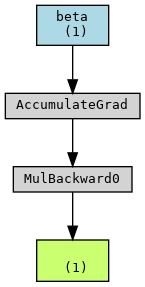

In [15]:
import torch
from torchviz import make_dot

# Create a dummy input tensor
dummy_input = torch.randn(flattened_params.shape, requires_grad=False)
# # Forward pass through the model
# with torch.no_grad():
# Compute the output of the model
dummy_output = r_model(dummy_input)
# Create a computation graph
graph = make_dot(dummy_output, params=dict(r_model.named_parameters()))
# Save the graph to a file
graph.render("model_graph", format="png")
# Display the graph
from IPython.display import Image
Image(filename="model_graph.png")

## Analytic version with ridge regression

In [10]:
import numpy as np

def recover_lambda(X: np.ndarray, y: np.ndarray, theta: np.ndarray, tol: float = 1e-6) -> float:
    """
    Recovers the ridge regularization parameter lambda from
    the stationarity condition: X^T (y - X theta) + lambda * theta = 0.
    
    Parameters:
        X (np.ndarray): Data matrix of shape (N, p).
        y (np.ndarray): Outcome vector of shape (N,).
        theta (np.ndarray): Ridge regression weights of shape (p,).
        tol (float): Tolerance for consistency check.
        
    Returns:
        float: The recovered lambda value.
        
    Raises:
        ValueError: If the recovered lambda is inconsistent across nonzero entries of theta.
    """
    # Compute the gradient component: X^T (y - X theta)
    grad = X.T @ (y - X @ theta)
    
    # Only consider indices where theta is nonzero to avoid division by zero.
    nonzero_idx = np.where(np.abs(theta) > tol)[0]
    if nonzero_idx.size == 0:
        raise ValueError("No nonzero entries in theta to recover lambda.")
    
    lambdas = -grad[nonzero_idx] / theta[nonzero_idx]
    
    # Check consistency of lambda across all coordinates.
    if not np.allclose(lambdas, lambdas[0], atol=tol):
        raise ValueError("Recovered lambda values are inconsistent across coordinates.")
    
    return lambdas[0]

# Example usage with synthetic data:
if __name__ == "__main__":
    np.random.seed(0)
    N, p = 100, 10
    X = np.random.randn(N, p)
    true_lambda = 2.5
    beta_true = np.random.randn(p)
    y = X @ beta_true + 0.1 * np.random.randn(N)
    
    # Ridge solution: (X^T X + lambda I)^{-1} X^T y
    theta_hat = np.linalg.inv(X.T @ X + true_lambda * np.eye(p)) @ (X.T @ y)
    
    recovered_lambda = recover_lambda(X, y, theta_hat)
    print(f"Recovered lambda: {recovered_lambda:.4f} (True lambda: {true_lambda})")

Recovered lambda: -2.5000 (True lambda: 2.5)


## Testing vjp

In [ ]:
params = dict(model.named_parameters())
# buffers = dict(model.named_buffers())

# Define function that returns model output
def model_output(params, x):
    return functional_call(model, params, (x,))

# def single_output(params, x_single):
#     # Return a scalar prediction per example 
#     return functional_call(model, params, (x_single,)).squeeze()

# Compute Jacobian of output w.r.t. weights
# x = torch.randn(10, input_dim)
gradient_wrt_params = jacrev(model_output)(params, X[:10])
# grad_per_sample = vmap(grad(model_output), in_dims=(None, 0))(params, X)
predictions = model_output(params, X[:10])
product = (-(y[:10]-predictions)).T @ gradient_wrt_params['linear.0.weight'].view(10, -1)
product.view(100, -1)

In [ ]:
# Compute Jacobian of output w.r.t. weights
# x = torch.randn(10, input_dim)
# gradient_wrt_params = jacrev(model_output)(params, X[:10])
with torch.no_grad():
    # vector-Jacobian product, returns function (model_output) applied to primals (params, X) 
    # and a function that computes the vector-Jacobian product
    predictions, vjp_func = vjp(model_output, params, X[:10])
    # vjp with residuals, then select the derivative w.r.t. params
    vjp_result =  vjp_func(-(y[:10] - predictions))[0] 
print(vjp_result['linear.0.weight'])